In [4]:
veri = {
    "date": ["17.09.2026", "17.09.2026", "17.09.2026", "18.09.2026", "18.09.2026", "18.09.2026", "19.09.2026"],
    "time": ["17:04", "20:04", "23:04", "02:04", "13:43", "18:00", "00:00"],
    "voltage_mV": [812, 814, 835, 812, 451, 457, 527]}
print(veri)
import pandas as pd                    

df = pd.DataFrame(veri)
df
df["date_time"] = pd.to_datetime(df["date"] + " " + df["time"], format="%d.%m.%Y %H:%M")
df

{'date': ['17.09.2026', '17.09.2026', '17.09.2026', '18.09.2026', '18.09.2026', '18.09.2026', '19.09.2026'], 'time': ['17:04', '20:04', '23:04', '02:04', '13:43', '18:00', '00:00'], 'voltage_mV': [812, 814, 835, 812, 451, 457, 527]}


,date,time,voltage_mV,date_time
0,17.09.2026,17:04,812,2026-09-17 17:04:00
1,17.09.2026,20:04,814,2026-09-17 20:04:00
2,17.09.2026,23:04,835,2026-09-17 23:04:00
3,18.09.2026,02:04,812,2026-09-18 02:04:00
4,18.09.2026,13:43,451,2026-09-18 13:43:00
5,18.09.2026,18:00,457,2026-09-18 18:00:00
6,19.09.2026,00:00,527,2026-09-19 00:00:00


In [5]:
df["total_time_hour"] = (df["date_time"] - df["date_time"].iloc[0]).dt.total_seconds() / 3600
df

,date,time,voltage_mV,date_time,total_time_hour
0,17.09.2026,17:04,812,2026-09-17 17:04:00,0.000000
1,17.09.2026,20:04,814,2026-09-17 20:04:00,3.000000
2,17.09.2026,23:04,835,2026-09-17 23:04:00,6.000000
3,18.09.2026,02:04,812,2026-09-18 02:04:00,9.000000
4,18.09.2026,13:43,451,2026-09-18 13:43:00,20.650000
5,18.09.2026,18:00,457,2026-09-18 18:00:00,24.933333
6,19.09.2026,00:00,527,2026-09-19 00:00:00,30.933333


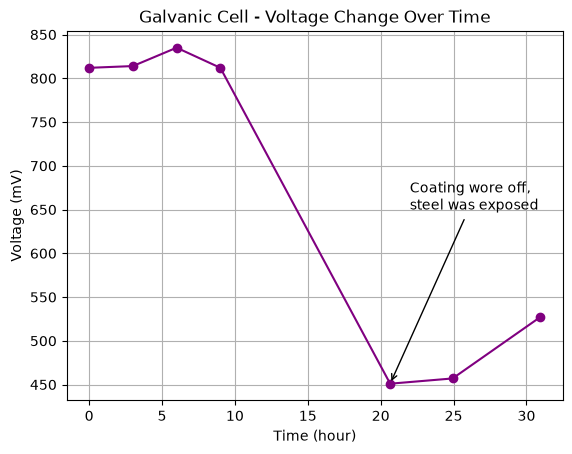

In [7]:
import matplotlib.pyplot as plt

plt.plot(df["total_time_hour"], df["voltage_mV"], marker="o", color="purple")
plt.xlabel("Time (hour)")
plt.ylabel("Voltage (mV)")
plt.title("Galvanic Cell - Voltage Change Over Time")
plt.grid(True)
plt.annotate(
    "Coating wore off,\nsteel was exposed",
    xy=(20.65, 451),
    xytext=(22, 650),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)
plt.savefig("voltage_time_plot.png", dpi=150, bbox_inches="tight")
plt.show()
